### Lecture et parsing du fichier JSONL de logs HTTP → DataFrame

In [1]:
import json
import sys
import pandas as pd
import numpy as np
import joblib

# ✅ Import featurize_http
sys.path.insert(0, "../ml")
from feature_extraction import featurize_http

path = "../ml/data/http_events.jsonl"
rows = []
with open(path, "r", encoding="utf-8", errors="ignore") as f:
    for line in f:
        line = line.strip()
        if not line:
            continue
        try:
            rows.append(json.loads(line))
        except:
            continue

# DataFrame brut
df_http = pd.DataFrame(rows)
print("📊 Total HTTP events:", len(df_http))

# ---- Nettoyage HTTP ----
BORING_PATHS = {
    "/", "/index.html", "/about", "/contact", "/api/health"
}
STATIC_EXTENSIONS = (
    ".css", ".js", ".png", ".jpg", ".jpeg", ".gif",
    ".svg", ".ico", ".woff", ".woff2", ".ttf"
)
IGNORED_METHODS = {"HEAD", "OPTIONS"}

# Colonnes utiles
for col in ["path", "query", "body", "user_agent", "method"]:
    if col not in df_http.columns:
        df_http[col] = ""
    else:
        df_http[col] = df_http[col].fillna("")

df_http["method"] = df_http["method"].replace("", "GET")

# Filtrage du bruit
df_http = df_http[~df_http["method"].str.upper().isin(IGNORED_METHODS)]
df_http = df_http[~df_http["path"].str.lower().str.endswith(STATIC_EXTENSIONS)]
df_http = df_http[
    ~(
        df_http["path"].str.lower().isin(BORING_PATHS)
        & (df_http["query"].str.strip() == "")
        & (df_http["body"].str.strip() == "")
    )
]

df_http = df_http.reset_index(drop=True)
print("✅ After cleaning HTTP events:", len(df_http))
df_http

📊 Total HTTP events: 6095
✅ After cleaning HTTP events: 6094


,timestamp,source_ip,service,method,path,query,user_agent,content_type,body
0,2026-04-25T14:09:24.287230Z,172.20.0.5,http,GET,/api/user/profile,id=42,Mozilla/5.0 (Windows NT 10.0; rv:109.0) Gecko/...,,
1,2026-04-25T14:09:24.507088Z,172.20.0.5,http,GET,/login,user=alice&redirect=/dashboard,Mozilla/5.0 (Windows NT 10.0; rv:109.0) Gecko/...,,
2,2026-04-25T14:09:24.983398Z,172.20.0.5,http,POST,/api/orders/create,,Mozilla/5.0 (iPhone; CPU iPhone OS 16_0 like M...,application/x-www-form-urlencoded,token=eyJhbGciOiJIUzI1NiJ9.abc.def
3,2026-04-25T14:09:25.351669Z,172.20.0.5,http,GET,/api/orders,status=pending,Mozilla/5.0 (X11; Linux x86_64) AppleWebKit/53...,,
4,2026-04-25T14:09:25.807800Z,172.20.0.5,http,GET,/verify,email=john@example.com,Mozilla/5.0 (Macintosh; Intel Mac OS X 10_15_7...,,
...,...,...,...,...,...,...,...,...,...
6089,2026-04-25T23:48:40.301808Z,172.20.0.1,http,GET,/upload,,Mozilla/5.0 (Windows NT 10.0; Win64; x64) Appl...,,
6090,2026-04-26T00:29:07.968398Z,172.20.0.1,http,GET,/upload,,Mozilla/5.0 (Windows NT 10.0; Win64; x64) Appl...,,
6091,2026-04-26T00:35:36.473828Z,172.20.0.1,http,POST,/api/parse,,curl/7.81.0,application/xml,"<!DOCTYPE x [<!ENTITY xxe SYSTEM ""file:///etc/..."
6092,2026-04-26T00:42:30.333588Z,172.20.0.1,http,GET,/api/search,q=dXNlcm5hbWU9YWRtaW4mcGFzc3dvcmQ9MTIz,curl/7.81.0,,


### Graphiques HTTP (top paths, top queries)

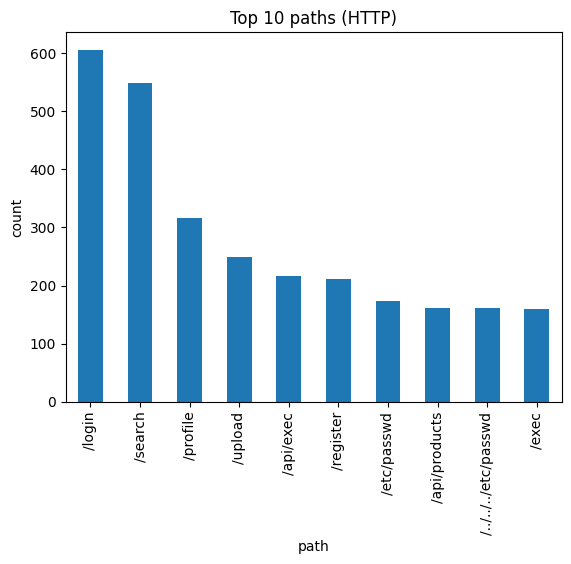

In [2]:
import matplotlib.pyplot as plt

df_http["path"].value_counts().head(10).plot(kind="bar")
plt.title("Top 10 paths (HTTP)")
plt.xlabel("path")
plt.ylabel("count")
plt.show()

### Top Queries

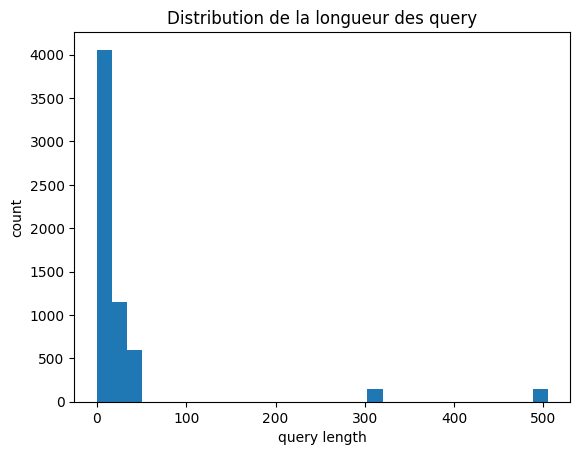

In [3]:
df_http["query_len"] = df_http["query"].fillna("").astype(str).str.len()

df_http["query_len"].plot(kind="hist", bins=30)
plt.title("Distribution de la longueur des query")
plt.xlabel("query length")
plt.ylabel("count")
plt.show()

### HTTP : scores du modèle

In [4]:
import sys
sys.path.append("../ml")

import joblib
import numpy as np
from feature_extraction import featurize_http

In [5]:
import importlib
import feature_extraction
importlib.reload(feature_extraction)
from feature_extraction import featurize_http

model_http = joblib.load("../ml/model_http.joblib")

# Verification
print("Modele attend :", model_http.n_features_in_, "features")
print("featurize_http produit :", len(featurize_http(df_http.iloc[0].to_dict())), "features")

assert model_http.n_features_in_ == len(featurize_http(df_http.iloc[0].to_dict())), \
    "Incoherence features — relance le kernel Jupyter"

X_http = np.array([
    featurize_http(row.to_dict())
    for _, row in df_http.iterrows()
], dtype=float)

print("X_http shape:", X_http.shape)  # doit afficher (n, 16)

scores_http = model_http.score_samples(X_http)
preds_http  = model_http.predict(X_http)

df_http["ml_score"] = scores_http
df_http["ml_pred"]  = preds_http

df_http.head()

Modele attend : 16 features
featurize_http produit : 16 features
X_http shape: (6094, 16)


,timestamp,source_ip,service,method,path,query,user_agent,content_type,body,query_len,ml_score,ml_pred
0,2026-04-25T14:09:24.287230Z,172.20.0.5,http,GET,/api/user/profile,id=42,Mozilla/5.0 (Windows NT 10.0; rv:109.0) Gecko/...,,,5,-0.539143,1
1,2026-04-25T14:09:24.507088Z,172.20.0.5,http,GET,/login,user=alice&redirect=/dashboard,Mozilla/5.0 (Windows NT 10.0; rv:109.0) Gecko/...,,,30,-0.550729,1
2,2026-04-25T14:09:24.983398Z,172.20.0.5,http,POST,/api/orders/create,,Mozilla/5.0 (iPhone; CPU iPhone OS 16_0 like M...,application/x-www-form-urlencoded,token=eyJhbGciOiJIUzI1NiJ9.abc.def,0,-0.414605,1
3,2026-04-25T14:09:25.351669Z,172.20.0.5,http,GET,/api/orders,status=pending,Mozilla/5.0 (X11; Linux x86_64) AppleWebKit/53...,,,14,-0.479653,1
4,2026-04-25T14:09:25.807800Z,172.20.0.5,http,GET,/verify,email=john@example.com,Mozilla/5.0 (Macintosh; Intel Mac OS X 10_15_7...,,,22,-0.496068,1


### Visualisation la distribution des scores HTTP

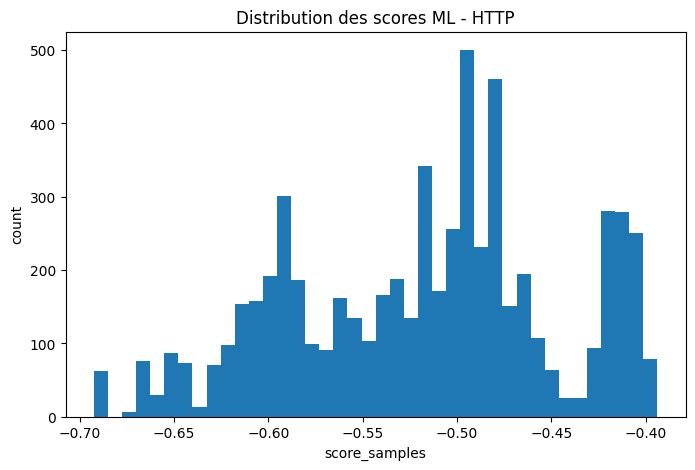

In [6]:
import matplotlib.pyplot as plt

plt.figure(figsize=(8,5))
plt.hist(df_http["ml_score"], bins=40)
plt.title("Distribution des scores ML - HTTP")
plt.xlabel("score_samples")
plt.ylabel("count")
plt.show()

### les anomalies HTTP les plus suspectes

In [7]:
anomalies_http = df_http[df_http["ml_pred"] == -1].copy()
anomalies_http = anomalies_http.sort_values("ml_score")

anomalies_http[["path", "query", "user_agent", "ml_score"]].head(10)

,path,query,user_agent,ml_score
1039,/../../../etc/passwd,,Nuclei - https://github.com/projectdiscovery/n...,-0.692535
5501,/../../../etc/passwd,,Nuclei - https://github.com/projectdiscovery/n...,-0.692535
507,/../../../etc/passwd,,Nuclei - https://github.com/projectdiscovery/n...,-0.692535
514,/../../../etc/passwd,,Nuclei - https://github.com/projectdiscovery/n...,-0.692535
826,/../../../etc/passwd,,Nuclei - https://github.com/projectdiscovery/n...,-0.692535
2645,/../../../etc/passwd,,Nuclei - https://github.com/projectdiscovery/n...,-0.692535
5724,/../../../etc/passwd,,Nuclei - https://github.com/projectdiscovery/n...,-0.692535
1413,/../../../etc/passwd,,curl/8.4.0,-0.691366
774,/../../../etc/passwd,,curl/8.4.0,-0.691366
1011,/../../../etc/passwd,,curl/8.4.0,-0.691366


### Taux d'anomalie HTTP

In [8]:
(len(df_http[df_http["ml_pred"] == -1]) / len(df_http)) * 100

13.767640301936332

In [9]:
print("HTTP anomalies:", round((df_http["ml_pred"] == -1).mean() * 100, 2), "%")

HTTP anomalies: 13.77 %
